# Object Detection

## Objektų aptikimo modelio pasirinkimas ir pritaikymas
Pasirinkite du objektų aptikimui apmokytus modelius iš https://github.com/pytorch/vision ar iš alternatyvaus šaltinio.
Pritaikykite objektų aptikimo modelį pasirinktoms nuotraukoms.
Pasiaiškinkite priežastis netinkamo objektų aptikimo ir kokiais veiksmais galima būtų šiuos netikslumus pašalinti.

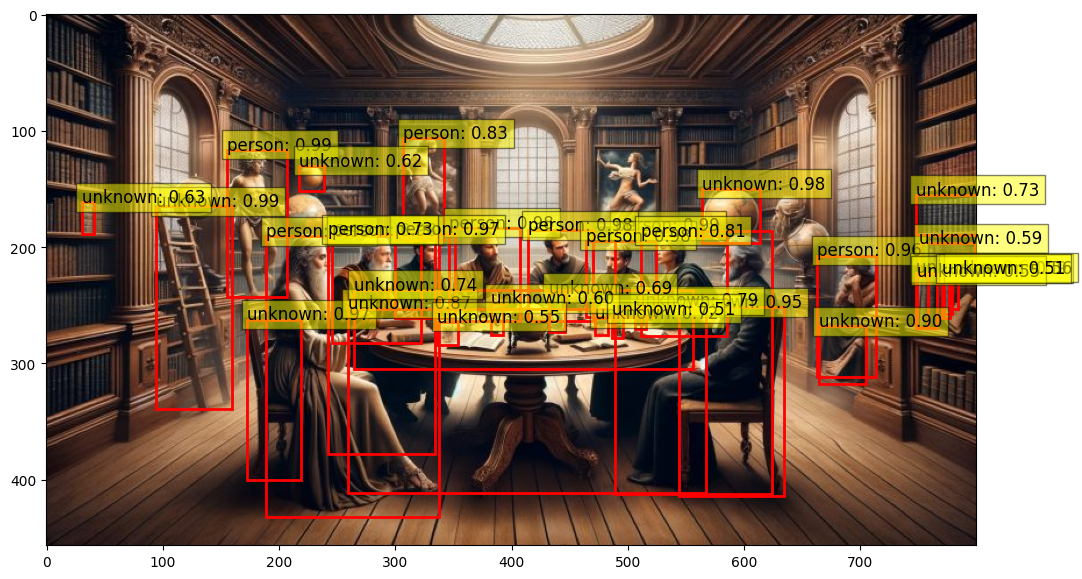

In [6]:
import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn, ssd300_vgg16
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Pasirenkame modelį: Faster R-CNN arba SSD
def load_model(model_name="fasterrcnn"):
    if model_name == "fasterrcnn":
        model = fasterrcnn_resnet50_fpn(pretrained=True)
    elif model_name == "ssd":
        model = ssd300_vgg16(pretrained=True)
    else:
        raise ValueError("Pasirinkite 'fasterrcnn' arba 'ssd'")
    
    model.eval()  # Modelis į vertinimo režimą
    return model

# Vaizdo apdorojimo funkcija
def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor()])
    return transform(image), image

# Nubrėžiame aptiktus objektus ant vaizdo
def plot_detections(image, predictions, threshold=0.5):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # COCO dataset kategorijos
    coco_labels = {1: "person", 2: "bicycle", 3: "car", 4: "motorcycle", 5: "airplane", 
                   6: "bus", 7: "train", 8: "truck", 9: "boat", 10: "traffic light"}

    for i, (box, score, label) in enumerate(zip(predictions["boxes"], predictions["scores"], predictions["labels"])):
        if score > threshold:  # Jei pasitikėjimas viršija slenkstį
            x1, y1, x2, y2 = box.detach().numpy()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            label_text = coco_labels.get(label.item(), "unknown")
            ax.text(x1, y1, f"{label_text}: {score:.2f}", bbox=dict(facecolor="yellow", alpha=0.5), fontsize=12)

    plt.show()

# Pritaikome modelį vaizdui
def detect_objects(image_path, model_name="fasterrcnn"):
    model = load_model(model_name)
    image_tensor, image = process_image(image_path)

    with torch.no_grad():
        prediction = model([image_tensor])  # Modelio prognozė

    plot_detections(image, prediction[0])

# Vykdymo pavyzdys
image_path = "test1.jpg"
detect_objects(image_path, model_name="fasterrcnn")

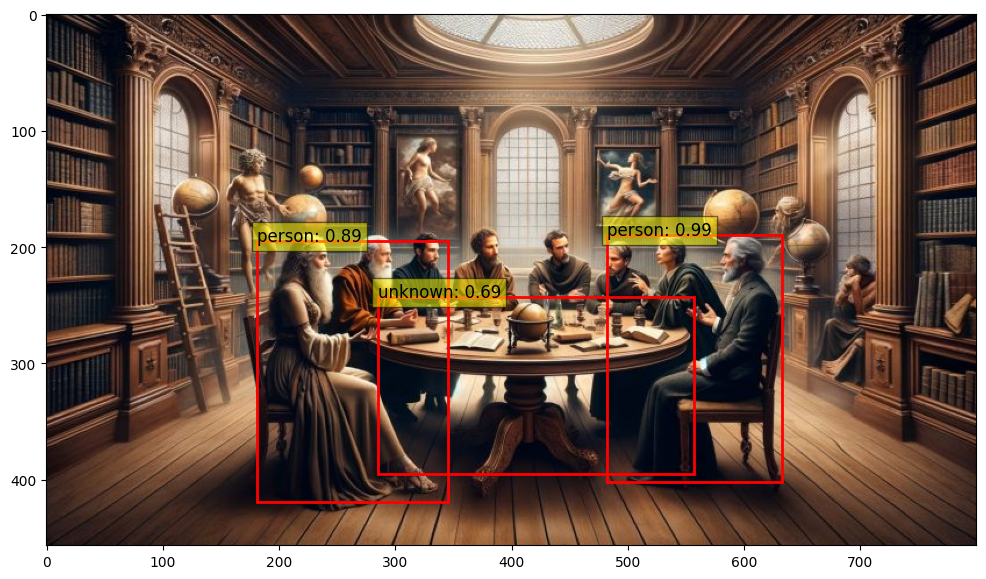

In [5]:
detect_objects(image_path, model_name="ssd")  # Galite pakeisti į "ssd"

## Vaizdo segmentavimo modelio pasirinkimas ir pritaikymas
Pasirinkite vieną vaizdo segmentavimo modelį.
Pritaikykite pasirinktą vaizdo segmentavimo modelį savo parsisiųstiems vaizdams.
Pasiaiškinkite priežastis netinkamo vaizdų segmentavimo ir kokiais veiksmais galima būtų šiuos netikslumus pašalinti.

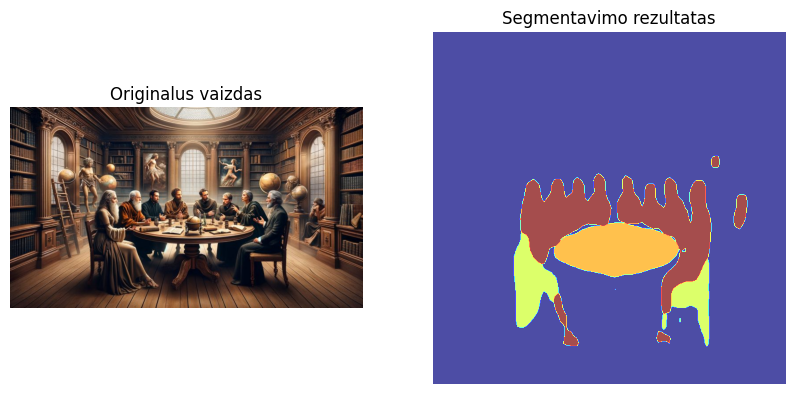

In [8]:
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Modelio įkėlimas
model = deeplabv3_resnet101(pretrained=True)
model.eval()

# Vaizdo apdorojimo funkcija
def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([
        T.Resize((520, 520)),  # Keičiame dydį, kad modelis geriau apdorotų
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0), image  # Pridedame dimensiją, kad tiktų modeliui

# Segmentavimo funkcija
def segment_image(image_path):
    image_tensor, image = process_image(image_path)

    with torch.no_grad():
        output = model(image_tensor)['out'][0]  # Gauname segmentavimo žemėlapį
    output_predictions = output.argmax(0).byte().cpu().numpy()  # Gauname klasių indeksus

    # Vaizdo atvaizdavimas
    plt.figure(figsize=(10, 5))

    # Originalus vaizdas
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Originalus vaizdas")
    plt.axis("off")

    # Segmentavimo rezultatas
    plt.subplot(1, 2, 2)
    plt.imshow(output_predictions, cmap="jet", alpha=0.7)  # Naudojame spalvų žemėlapį
    plt.title("Segmentavimo rezultatas")
    plt.axis("off")

    plt.show()

# Testavimas su nuotrauka
image_path = "test1.jpg"
segment_image(image_path)

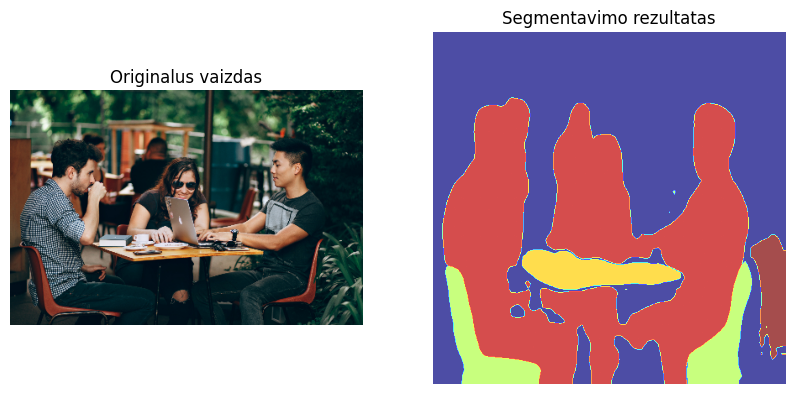

In [9]:
# Testavimas su nuotrauka
image_path = "test2.jpg"
segment_image(image_path)

0: 448x640 3 persons, 1 cup, 3 chairs, 1 laptop, 112.8ms
Speed: 1.8ms preprocess, 112.8ms inference, 3.1ms postprocess per image at shape (1, 3, 448, 640)


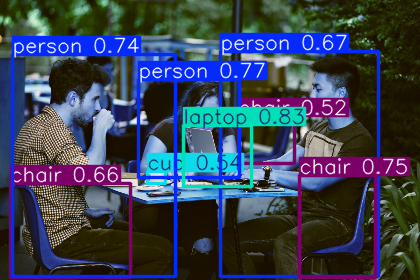

In [11]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Modelio įkėlimas
model = YOLO("yolov8n.pt")  # Naudojame "n" versiją (nano – greičiausias, bet mažesnis tikslumas)

# Vaizdo analizės funkcija
def detect_objects(image_path):
    # Įkeliame vaizdą
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # OpenCV naudoja BGR, o mums reikia RGB

    # Aptikimas su YOLO
    results = model(image)

    # Atvaizduojame rezultatus
    for r in results:
        r.show()  # Parodo vaizdą su aptiktais objektais

# Paleidimas su pasirinktu vaizdu
image_path = "test2.jpg"  # Pakeiskite į savo vaizdo kelią
detect_objects(image_path)

## 4. Vaizdų rinkinio automatizuoto apdorojimo sprendimo paruošimas
Įgyvendinkite algoritmą, kuris pritaiko objektų aptikimo modelį visiems vaizdams, esantiems nurodytame (jūsų sukurtame) kataloge.
Įgyvendinkite algoritmą, kuris susegmentuoja visus vaizdus, esančius jųsų sukurtame kataloge.

YOLOv8 objektų aptikimui kataloge

In [13]:
import os
from ultralytics import YOLO

# Modelio įkėlimas
model = YOLO("yolov8n.pt")

# Katalogai
input_folder = "input_images"  # Čia patalpinkite originalius vaizdus
output_folder = "output_yolo_detection"  # Rezultatų katalogas
os.makedirs(output_folder, exist_ok=True)

# Vaizdų apdorojimas kataloge
def detect_objects_in_folder():
    for image_name in os.listdir(input_folder):
        image_path = os.path.join(input_folder, image_name)
        output_path = os.path.join(output_folder, image_name)

        # Aptikimas su YOLO
        results = model(image_path)

        # Išsaugome apdorotą vaizdą
        results[0].save(filename=output_path)

# Paleidžiame objektų aptikimą kataloge
detect_objects_in_folder()
print(f"YOLO aptikimo rezultatai išsaugoti kataloge: {output_folder}")

image 1/1 /workspaces/MSc-Image-Processing/04Lab/input_images/input2.jpeg: 480x640 (no detections), 89.0ms
Speed: 2.9ms preprocess, 89.0ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /workspaces/MSc-Image-Processing/04Lab/input_images/input4.jpg: 640x480 1 person, 1 handbag, 93.0ms
Speed: 1.7ms preprocess, 93.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /workspaces/MSc-Image-Processing/04Lab/input_images/input1.jpg: 480x640 1 train, 87.2ms
Speed: 2.8ms preprocess, 87.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /workspaces/MSc-Image-Processing/04Lab/input_images/input3.jpeg: 480x640 1 chair, 1 couch, 89.2ms
Speed: 2.9ms preprocess, 89.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /workspaces/MSc-Image-Processing/04Lab/input_images/input5.jpg: 544x640 2 persons, 1 chair, 136.2ms
Speed: 3.5ms preprocess, 136.2ms inference, 1.0ms postprocess per image at 

Vaizdų segmentavimas kataloge

In [14]:
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import os
import numpy as np
import cv2
from PIL import Image

# Modelio įkėlimas
model = deeplabv3_resnet101(pretrained=True)
model.eval()

# Katalogai
input_folder = "input_images"
output_folder = "output_segmentation"
os.makedirs(output_folder, exist_ok=True)

# Vaizdo apdorojimo funkcija
def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([
        T.Resize((520, 520)),  # Modelio reikalaujamas dydis
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0), image

# Segmentavimo funkcija
def segment_images_in_folder():
    for image_name in os.listdir(input_folder):
        image_path = os.path.join(input_folder, image_name)
        image_tensor, image = process_image(image_path)

        with torch.no_grad():
            output = model(image_tensor)['out'][0]
        output_predictions = output.argmax(0).byte().cpu().numpy()

        # Segmentacijos rezultatų spalvinimas
        segmentation_colored = np.array(output_predictions * 10, dtype=np.uint8)
        segmentation_colored = cv2.applyColorMap(segmentation_colored, cv2.COLORMAP_JET)

        output_path = os.path.join(output_folder, image_name)
        cv2.imwrite(output_path, segmentation_colored)

# Paleidžiame segmentavimą kataloge
segment_images_in_folder()
print(f"Segmentacijos rezultatai išsaugoti kataloge: {output_folder}")

/home/codespace/.python/current/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/codespace/.python/current/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Segmentacijos rezultatai išsaugoti kataloge: output_segmentation
